# Test 2: วิเคราะห์ข้อมูลจาก PLC ด้วย Pandas
ต่อจาก `test1.ipynb` เราจะสร้าง Log จำลองของเครื่องจักร ตรวจ Alarm สรุปข้อมูล และวาดกราฟ  
รันทีละ Cell ด้วย **Shift + Enter**

In [9]:
# 1) นำเข้าไลบรารี
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# 2) สร้างข้อมูล Log จำลองจาก PLC
plc_log = pd.DataFrame({
    "timestamp": pd.date_range("2026-09-18 08:00", periods=8, freq="5min"),
    "machine": ["M01", "M01", "M01", "M01", "M02", "M02", "M02", "M02"],
    "temperature": [55.0, 62.5, 81.2, 76.4, 48.0, 58.2, 85.5, 67.0],
    "pressure": [4.8, 5.0, 5.4, 5.1, 4.7, 4.9, 5.6, 5.0],
    "motor_running": [True, True, False, True, True, True, False, True],
})
plc_log

,timestamp,machine,temperature,pressure,motor_running
0,2026-09-18 08:00:00,M01,55.0,4.8,True
1,2026-09-18 08:05:00,M01,62.5,5.0,True
2,2026-09-18 08:10:00,M01,81.2,5.4,False
3,2026-09-18 08:15:00,M01,76.4,5.1,True
4,2026-09-18 08:20:00,M02,48.0,4.7,True
5,2026-09-18 08:25:00,M02,58.2,4.9,True
6,2026-09-18 08:30:00,M02,85.5,5.6,False
7,2026-09-18 08:35:00,M02,67.0,5.0,True


In [11]:
# 3) สำรวจข้อมูลเบื้องต้น
print("จำนวนแถวและคอลัมน์:", plc_log.shape)
print("\nชนิดข้อมูล:")
print(plc_log.dtypes)
print("\nสถิติของค่าที่วัดได้:")
plc_log[["temperature", "pressure"]].describe()

จำนวนแถวและคอลัมน์: (8, 5)

ชนิดข้อมูล:
timestamp        datetime64[ns]
machine                  object
temperature             float64
pressure                float64
motor_running              bool
dtype: object

สถิติของค่าที่วัดได้:


,temperature,pressure
count,8.000000,8.000000
mean,66.725000,5.062500
std,13.279065,0.302076
min,48.000000,4.700000
25%,57.400000,4.875000
50%,64.750000,5.000000
75%,77.600000,5.175000
max,85.500000,5.600000


In [12]:
# 4) สร้างสถานะจากค่าอุณหภูมิ
def classify_temperature(value):
    if value > 80:
        return "ALARM"
    if value > 60:
        return "WARNING"
    return "NORMAL"

plc_log["status"] = plc_log["temperature"].apply(classify_temperature)
plc_log

,timestamp,machine,temperature,pressure,motor_running,status
0,2026-09-18 08:00:00,M01,55.0,4.8,True,NORMAL
1,2026-09-18 08:05:00,M01,62.5,5.0,True,WARNING
2,2026-09-18 08:10:00,M01,81.2,5.4,False,ALARM
3,2026-09-18 08:15:00,M01,76.4,5.1,True,WARNING
4,2026-09-18 08:20:00,M02,48.0,4.7,True,NORMAL
5,2026-09-18 08:25:00,M02,58.2,4.9,True,NORMAL
6,2026-09-18 08:30:00,M02,85.5,5.6,False,ALARM
7,2026-09-18 08:35:00,M02,67.0,5.0,True,WARNING


In [13]:
# 5) กรองเฉพาะเหตุการณ์ผิดปกติ
alarm_rows = plc_log[plc_log["status"] == "ALARM"]
print(f"พบ Alarm ทั้งหมด {len(alarm_rows)} ครั้ง")
alarm_rows[["timestamp", "machine", "temperature", "pressure"]]

พบ Alarm ทั้งหมด 2 ครั้ง


,timestamp,machine,temperature,pressure
2,2026-09-18 08:10:00,M01,81.2,5.4
6,2026-09-18 08:30:00,M02,85.5,5.6


In [14]:
# 6) สรุปค่าเฉลี่ยและค่าสูงสุด แยกตามเครื่องจักร
machine_summary = plc_log.groupby("machine").agg(
    average_temperature=("temperature", "mean"),
    maximum_temperature=("temperature", "max"),
    average_pressure=("pressure", "mean"),
    alarm_count=("status", lambda values: (values == "ALARM").sum()),
).round(2)
machine_summary

,average_temperature,maximum_temperature,average_pressure,alarm_count
machine,,,,
M01,68.78,81.2,5.08,1
M02,64.68,85.5,5.05,1


In [15]:
# 7) หาแนวโน้มด้วยค่าเฉลี่ยเคลื่อนที่ 3 จุด
plc_log["temperature_ma3"] = (
    plc_log.groupby("machine")["temperature"]
    .transform(lambda values: values.rolling(3, min_periods=1).mean())
)
plc_log[["timestamp", "machine", "temperature", "temperature_ma3"]]

,timestamp,machine,temperature,temperature_ma3
0,2026-09-18 08:00:00,M01,55.0,55.000000
1,2026-09-18 08:05:00,M01,62.5,58.750000
2,2026-09-18 08:10:00,M01,81.2,66.233333
3,2026-09-18 08:15:00,M01,76.4,73.366667
4,2026-09-18 08:20:00,M02,48.0,48.000000
5,2026-09-18 08:25:00,M02,58.2,53.100000
6,2026-09-18 08:30:00,M02,85.5,63.900000
7,2026-09-18 08:35:00,M02,67.0,70.233333


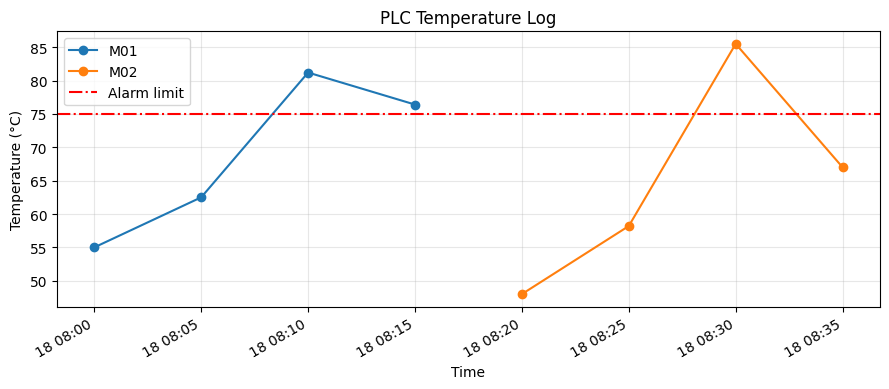

In [26]:
# 8) วาดกราฟอุณหภูมิ พร้อมเส้น Alarm ที่ 80 °C
fig, ax = plt.subplots(figsize=(9, 4))

for machine, data in plc_log.groupby("machine"):
    ax.plot(data["timestamp"], data["temperature"], marker="o", label=machine)

ax.axhline(75, color="red", linestyle="dashdot", label="Alarm limit")
ax.set_title("PLC Temperature Log")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (°C)")
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## แบบฝึกหัด
1. เปลี่ยน Alarm limit จาก 80 เป็น 75 °C แล้วนับ Alarm ใหม่
2. กรองข้อมูลเฉพาะเครื่อง `M02`
3. เพิ่มคอลัมน์ `speed_rpm` และหาค่าเฉลี่ยแยกตามเครื่อง
4. เปลี่ยนกราฟให้แสดง Pressure แทน Temperature
5. ทดลองใช้ `plc_log.to_csv("plc_log.csv", index=False)` เพื่อส่งออกข้อมูล